# Sentiment Classification Using RNN

## Task: Sentiment analysis determines if a given text expresses a positive or negative emotion. You will train an LSTM-based sentiment classifier using the IMDB dataset.

1.	Load the IMDB sentiment dataset (tensorflow.keras.datasets.imdb).
2.	Preprocess the text data by tokenization and padding sequences.
3.	Train an LSTM-based model to classify reviews as positive or negative.
4.	Generate a confusion matrix and classification report (accuracy, precision, recall, F1-score).
5.	Interpret why precision-recall tradeoff is important in sentiment classification.


In [29]:
import tensorflow as tf

In [30]:
# Load the IMDB dataset
imdb = tf.keras.datasets.imdb

vocabulary_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=vocabulary_size
)

print(f"Training samples: {len(x_train)}")
print(f"Testing samples: {len(x_test)}")


Training samples: 25000
Testing samples: 25000


In [31]:
print(x_train[0][:100])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16]


In [32]:
# Padding the sequences to ensure uniform input size
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

x_train = pad_sequences(
    x_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print(x_train.shape)
print(x_test.shape)

(25000, 200)
(25000, 200)


In [33]:
# Define the LSTM model

max_length = 200

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_length,)),
    
    tf.keras.layers.Embedding(
        input_dim=vocabulary_size,
        output_dim=128,
        mask_zero=True
    ),

    tf.keras.layers.LSTM(64),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [34]:
# Train the model 
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)


Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.7724 - loss: 0.4713 - val_accuracy: 0.8540 - val_loss: 0.3542
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.8867 - loss: 0.2905 - val_accuracy: 0.8550 - val_loss: 0.3395
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9195 - loss: 0.2144 - val_accuracy: 0.8342 - val_loss: 0.3897
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9417 - loss: 0.1607 - val_accuracy: 0.8428 - val_loss: 0.4203
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9579 - loss: 0.1201 - val_accuracy: 0.8528 - val_loss: 0.4412
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9693 - loss: 0.0883 - val_accuracy: 0.8508 - val_loss: 0.5334
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.9683 - loss: 0.0899 - val_accuracy: 0.8456 - val_loss: 0.5458
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9819 - loss: 0.0565 - 

In [42]:
#Model evaluation
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8219 - loss: 0.8112
Test Loss: 0.8111875653266907
Test Accuracy: 0.8218799829483032


782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step


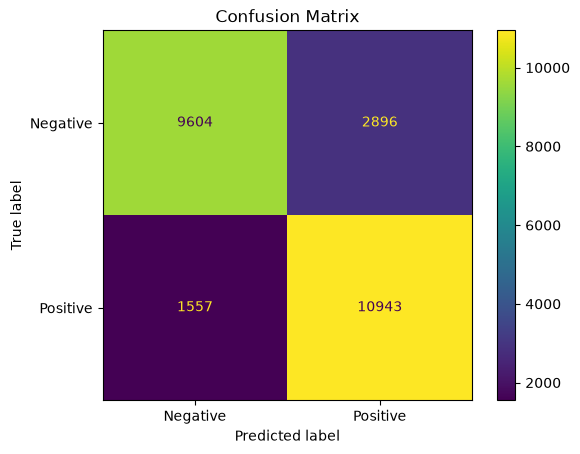

In [40]:
# Model predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_prob = model.predict(x_test)

y_pred = (
    y_prob >= 0.5
).astype(int).flatten()

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [41]:
# Classification report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.86      0.77      0.81     12500
    Positive       0.79      0.88      0.83     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



## Interpret why precision-recall tradeoff is important in sentiment classification.

### Answer:

The precision-recall tradeoff is important in sentiment classification because improving one can sometimes reduce the other. Precision tells us how often the model is correct when it predicts a review as positive, while recall tells us how many of the actual positive reviews the model successfully finds. For example, if we make the model very strict before labeling a review as positive, precision may increase because there are fewer false positives, but recall may decrease because some real positive reviews are missed. Therefore, the best balance depends on whether false positive or false negative predictions are more important in the application.